In [39]:
import torch
import torchvision
from torchvision import transforms
from torchvision.transforms import Resize, ToTensor, Pad
import sys
sys.path.append('../')
from DataType.ElectricField import ElectricField
from LightSource.Gaussian_beam import Guassian_beam
from Props.ASM_Prop import ASM_prop
from Props.RSC_Prop import RSC_prop
from Components.Thin_Lens import Thin_LensElement
from Components.Aperture import ApertureElement
from Components.QuantizedDOE import SoftGumbelQuantizedDOELayerv3 as SoftGumbelQuantizedDOELayer
from Components.QuantizedDOE import NaiveGumbelQuantizedDOELayer
from Components.QuantizedDOE import PSQuantizedDOELayer
from Components.QuantizedDOE import STEQuantizedDOELayer
from Components.QuantizedDOE import FullPrecisionDOELayer
from Components.QuantizedDOE import FixDOEElement
from utils.Helper_Functions import normalize, DOE_xyz_cordinates_Generator
from utils.units import *
import numpy as np
import scipy.io
import os
import time
import torch.nn as nn
import matplotlib.pyplot as plt

# 1. Set simulation parameters

In [40]:
# Hologram parameters (high-temp resin)
epsilon = 2.66
tand = 0.003
    
input_field_shape = [100, 100]
input_dxy = 1 * mm
doe_shape = [100, 100]
doe_dxy = 1 * mm
    
    
c0 = 2.998e8
f2 = 300e9  # 0.3 THz

wavelengths = c0 / f2
#print("The number of wavelengths: " +  str(wavelengths.shape[0]))

# all parameters of DOE optimization
doe_params = {
    'doe_size': doe_shape,
    'doe_dxy' : doe_dxy,
    'doe_level': 4,
    'look_up_table': [0*mm, 0.2*mm, 0.4*mm, 0.6*mm],
    'num_unit': None,
    'height_constraint_max': 0.8 * mm,
    'tolerance': 10 * um,  
    'material': [epsilon, tand]
}

optim_params = {
    'c_s': 100,   # a number to boost the score (higher more robust to gumbel noise)
    'tau_max': 2.5, # maximum value of tau
    'tau_min': 1.5  # minimum value of tau
}


# layer num and distance between two layer
num_layer = 4
d_layer = 20 * mm

# training parameter
batch_size = 128

# 2. Define a 3-layers diffractive optical neural network (DONN)

In [41]:
class DONN(nn.Module):
    """ simulate a diffractive optical neural network with multiple DOEs
        various quantized optimization method can be used here
    """
    def __init__(self, 
                 input_dxy, 
                 input_field_shape,
                 doe_params, 
                 optim_params,
                 wavelengths, 
                 num_layer, 
                 d_layer,
                 q_method,
                 device='cuda:0'):
        super().__init__()
        
        self.input_dxy = input_dxy
        self.input_field_shape = input_field_shape
        self.doe_params = doe_params
        self.optim_params = optim_params
        
        self.wavelengths = wavelengths

        self.num_layer = num_layer
        self.d_layer = d_layer

        
        self.asm_prop2layer = ASM_prop(z_distance=30 * mm, 
                                       bandlimit_type='exact', 
                                       padding_scale=2, 
                                       bandlimit_kernel=True)

        self.aperture = ApertureElement(aperture_type = 'rect',
                                        aperture_size = 0.08)

        self.device = device

        self.iter_frac = None
        
        # define the difffractive layers
        self.asm_prop_layers = nn.ModuleList([
                                    ASM_prop(z_distance=self.d_layer, 
                                             bandlimit_type='exact', 
                                             padding_scale=2, 
                                             bandlimit_kernel=True) for i in range(self.num_layer)
                                    ])
        if q_method == None:
            self.does = nn.ModuleList([FullPrecisionDOELayer(self.doe_params) for i in range(self.num_layer)])
            
        elif q_method == 'sgs':
            self.does = nn.ModuleList([SoftGumbelQuantizedDOELayer(self.doe_params, self.optim_params) for i in range(self.num_layer)])
            
        elif q_method == 'gs':
            self.does = nn.ModuleList([NaiveGumbelQuantizedDOELayer(self.doe_params, self.optim_params) for i in range(self.num_layer)])
            
        elif q_method == 'psq':
            optim_params = {'c_s': 300,'tau_max': 50,'tau_min': 1}
            self.does = nn.ModuleList([PSQuantizedDOELayer(self.doe_params, optim_params) for i in range(self.num_layer)])
            
        elif q_method == 'ste':
            self.does = nn.ModuleList([STEQuantizedDOELayer(self.doe_params, self.optim_params) for i in range(self.num_layer)])

    def encode_object(self, u):
        # Create plane wave
        amplitude_fields = torch.ones(1, 1, self.input_field_shape[0], self.input_field_shape[1], device=self.device) * u
        phase_fields = torch.zeros_like(amplitude_fields, device=self.device)
        # Combine amplitude and phase to form complex electric fields
        electric_fields = amplitude_fields * torch.exp(1j * phase_fields) # add Batch dimension

        field = ElectricField(
                data=electric_fields, 
                wavelengths=self.wavelengths,
                spacing=self.input_dxy
        )
        
        field = self.asm_prop2layer(field)
        field = self.aperture(field)
        
        return field
    
    def forward(self, u, iter_frac=None):

        self.iter_frac = iter_frac
        field = self.encode_object(u)
        #print(iter_frac)

        for i in range(self.num_layer):
            field = self.does[i](field, self.iter_frac)
            field = self.asm_prop_layers[i](field)
            field = self.aperture(field)
    
        return field

In [42]:
donn = DONN(input_dxy=input_dxy, 
            input_field_shape=input_field_shape, 
            doe_params=doe_params, 
            optim_params=optim_params,
            wavelengths=wavelengths, 
            num_layer=num_layer,
            d_layer=d_layer, 
            q_method=None)

In [43]:
donn

DONN(
  (asm_prop2layer): ASM_prop()
  (aperture): ApertureElement()
  (asm_prop_layers): ModuleList(
    (0-3): 4 x ASM_prop()
  )
  (does): ModuleList(
    (0-3): 4 x FullPrecisionDOELayer()
  )
)

# 3. Define a Label Generator and Dataloader

## 3.1 MINST Dataloader

In [44]:
import torch
import torchvision.transforms as transforms
from PIL import Image

def thresholding(image):
    # Convert image to a PyTorch tensor
    image_tensor = transforms.functional.to_tensor(image)
    
    # Apply a threshold (e.g., 0.5 for the middle intensity in normalized range)
    binary_tensor = (image_tensor > 0.4).float()
    
    # Convert tensor back to PIL image
    return transforms.functional.to_pil_image(binary_tensor)

trans =transforms.Compose([Resize(80), Pad(10), transforms.Lambda(thresholding), ToTensor()])

mnist_train = torchvision.datasets.MNIST(
        root="./data", train=True, transform=trans, download=True)
mnist_test = torchvision.datasets.MNIST(
        root="./data", train=False, transform=trans, download=True) 
train_set, val_set = torch.utils.data.random_split(mnist_train, [len(mnist_train)-5000, 5000])
    
# train, validation and test
train_loader = torch.utils.data.DataLoader(train_set, 
                                           batch_size=batch_size,
                                           shuffle=True, num_workers=8,pin_memory=True)
val_loader = torch.utils.data.DataLoader(val_set, 
                                         batch_size=batch_size,
                                         shuffle=True, num_workers=4)

test_loader = torch.utils.data.DataLoader(mnist_test, 
                                         batch_size=batch_size,
                                         shuffle=True, num_workers=4)

10000

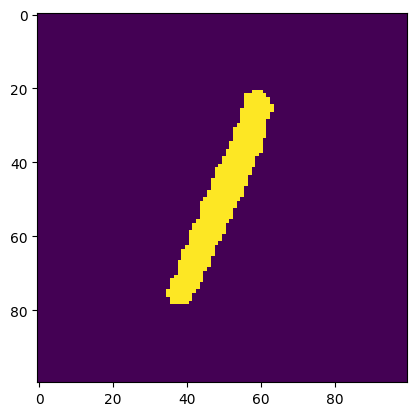

In [45]:
# Function to visualize images
dataiter = iter(train_loader)
images, labels = next(dataiter)

plt.imshow(images[0, 0, :, :])

len(mnist_test)

## 3.2 Label Gemerator

In [46]:
def rect(X,w):
    Y = torch.zeros(X.shape)
    Y[torch.abs(X)<w]=1
    return Y.cuda()

L = 100
M = 100
dx = L/M
x1 = torch.linspace(-L/2, L/2, M)
X1, Y1 = torch.meshgrid(x1, x1, indexing='ij')
w = 3
yb = 12
xb = 12

cens = [[-xb, yb],[0, yb], [xb, yb],
        [-xb/2-xb,0],[-xb/2,0],[xb/2,0],[xb/2+xb,0],
        [-xb, -yb],[0, -yb], [xb, -yb]]
cens2 = [] 
w2 = int( w*M/L+1)
# labels = label_generator()
for x, y in cens:
    cens2.append([int(M/2+x/L*M),int(M/2+y/L*M)]) 

def label_generator():

    labels = torch.zeros(10,M,M)
    for k in range(10):
        labels[k] = rect(X1-cens[k][0],w)*rect(Y1-cens[k][1],w)
    return labels.unsqueeze(1)


def eval_accuracy(target, label):
        
    label_hat = torch.zeros(target.size(0), 10).cuda()
    # print(label_hat[:,1].size())
    for k in range(10):
        x, y = cens2[k]
        # label_hat[:,k] = target[:, :, y-w2:y+w2, x-w2:x+w2].sum(dim=(2,3)).squeeze(1)
        label_hat[:,k] = target[:, :, x-w2:x+w2, y-w2:y+w2].sum(dim=(2,3)).squeeze(1)          
    # print(label_hat.size())
    label_hat = label_hat.argmax(1)
    acc = (label_hat == label.cuda()).sum()/label.size(0)
    
    return acc.data, label_hat

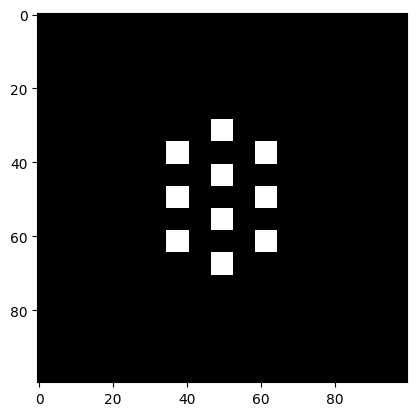

In [47]:
test = torch.tensor([0,1,1,3,4,3,6,7,8,9])
a = label_generator()
target = a[test]
acc = eval_accuracy(target, test)
a = torch.sum(a, axis=0)
plt.imshow(a[0],cmap='gray')

## 3.3 define loss function

In [48]:
def npcc_loss(X, Y):
    X_mean = torch.mean(X, dim=(2,3), keepdim=True)
    Y_mean = torch.mean(Y,dim=(2,3), keepdim=True) 
    a = torch.sum((X - X_mean)*(Y - Y_mean), dim=(2,3), keepdim=True)
    b = torch.sqrt(torch.sum((X - X_mean)**2, dim=(2,3), keepdim=True)
                   *torch.sum((Y - Y_mean)**2, dim=(2,3), keepdim=True))
    npcc = torch.mean(-a/b)
    return npcc

# 4. Define a train and validation pipelines

In [36]:
def train(onn,
          criterion, 
          optimizer, 
          train_loader,
          val_loader,
          save_path,
          epoch_num=50,
          device='cuda:0'):
    
    label_set = label_generator()
    train_losses = []
    train_accies = []
    val_losses = []
    val_accies = []

    for epoch in range(1, epoch_num+1):  
        train_loss = 0.0
        acc_sum = 0.0
        for i, data in enumerate(train_loader, 0):
            inputs, labels = data
            inputs = inputs.to(device)
            # labels = labels.to(device)
            targets = label_set[labels]
            targets = targets.to(device)
            optimizer.zero_grad()
            outputs = onn(inputs, iter_frac=epoch/epoch_num)
            I = normalize(torch.abs(outputs.data)**2)
      
            loss = criterion(I, targets)
            loss.backward()

            optimizer.step()

            train_loss += loss.item()
            train_acc, label_hat= eval_accuracy(I ,labels)
            acc_sum += train_acc.item()
           
            if (i+1) % 200 == 0:    # print every 2000 mini-batches
                # acc = accuracy(outputs, labels)
                train_log = f'epoch {epoch } {i+1}, train loss: {train_loss/200: 5f},train accuracy: {acc_sum/200: 5f}'
    
                train_losses.append(train_loss /200)
                train_accies.append(acc_sum/200)
                train_loss = 0.0
                acc_sum = 0.0
                torch.save(onn, save_path+'/onn_psq'+str(epoch+1)+'.pt')
                with torch.no_grad():
                    val_loss, val_acc, I_val, labels_val = validation(onn, val_loader,criterion, iter_frac=epoch/epoch_num)
                    val_log =f'validation loss:{val_loss :5f}, validation accuracy: {val_acc:5f}'
                    val_losses.append(val_loss)
                    val_accies.append(val_acc)
                print(train_log,'\n', val_log)
                with open(save_path + '/log.txt', "a", encoding='utf-8') as f:
                    f.write(train_log+'\n')
                    f.write(val_log+'\n')
    return onn, train_losses, train_accies, val_losses, val_accies, I_val, labels_val

In [37]:
def validation(onn, val_loader,criterion, iter_frac, device='cuda:0'):
    val_loss_sum = .0
    val_acc_sum = .0
    label_set = label_generator()
    for i, data in enumerate(val_loader, 0):
        inputs, labels = data
        inputs = inputs.to(device)
        targets = label_set[labels]
        targets = targets.to(device)
        outputs = onn(inputs, iter_frac)
        I = normalize(torch.abs(outputs.data)**2)
        val_loss = criterion(I, targets)
        val_acc, _= eval_accuracy(I ,labels)
        val_loss_sum += val_loss.item()
        val_acc_sum += val_acc.item()
        
    return val_loss_sum/(i+1), val_acc_sum/(i+1), I, labels


def conf_matrix(onn, val_loader, criterion, iter_frac=1, device='cuda:0'):
    from sklearn.metrics import confusion_matrix
    val_loss_sum = .0
    val_acc_sum = .0
    all_labels = []
    all_preds = []
    label_set = label_generator()
    
    for i, data in enumerate(val_loader, 0):
        inputs, labels = data
        inputs = inputs.to(device)
        targets = label_set[labels]
        targets = targets.to(device)
        outputs = onn(inputs, iter_frac)
        I = normalize(torch.abs(outputs.data)**2)
        val_loss = criterion(I, targets)
        val_acc, preds = eval_accuracy(I, labels)
        
        val_loss_sum += val_loss.item()
        val_acc_sum += val_acc.item()
        
        # Collect the true labels and predictions
        all_labels.append(labels.cpu().numpy())
        all_preds.append(preds.cpu().numpy())
    
    # Convert lists to numpy arrays
    all_labels = np.concatenate(all_labels)
    all_preds = np.concatenate(all_preds)
    
    # Compute confusion matrix
    conf_matrix = confusion_matrix(all_labels, all_preds)
    
    return conf_matrix, val_acc_sum/(i+1), I, labels

In [38]:
# 5. Training the model with different quantized methods

from torch import optim

################ train ###############################
file_path = 'model'
if os.path.exists(file_path) == False:
    os.makedirs(file_path)

device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

donn = DONN(input_dxy=input_dxy, 
            input_field_shape=input_field_shape, 
            doe_params=doe_params, 
            optim_params=optim_params,
            wavelengths=wavelengths, 
            num_layer=num_layer,
            d_layer=d_layer, 
            q_method='psq', 
            device=device)

epoch_num = 50
optimizer = optim.AdamW(donn.parameters(), lr=0.1)
criterion = npcc_loss

################################ train ####################################
start_time = time.time()
donn, train_losses, train_accies, val_losses, val_accies, I_val, labels_val =\
            train(donn,criterion, optimizer,
                  train_loader,val_loader, 
                  file_path, epoch_num)    
    
end_time = time.time()
print(f'runing time: {end_time - start_time: 5f}s')

The critical distance is [0.26003873] m, the TF will be fine during the sampling !
The critical distance is [0.26003873] m, the TF will be fine during the sampling !
The critical distance is [0.26003873] m, the TF will be fine during the sampling !
The critical distance is [0.26003873] m, the TF will be fine during the sampling !
The critical distance is [0.26003873] m, the TF will be fine during the sampling !
epoch 1 200, train loss: -0.534611,train accuracy:  0.721094 
 validation loss:-0.589961, validation accuracy: 0.784961
epoch 1 400, train loss: -0.596152,train accuracy:  0.783477 
 validation loss:-0.603048, validation accuracy: 0.788086
epoch 2 200, train loss: -0.619568,train accuracy:  0.797148 
 validation loss:-0.626201, validation accuracy: 0.806250
epoch 2 400, train loss: -0.623273,train accuracy:  0.801953 
 validation loss:-0.626082, validation accuracy: 0.813672
epoch 3 200, train loss: -0.630897,train accuracy:  0.805039 
 validation loss:-0.634687, validation accu

In [ ]:
epochs = [k for k in range(1,epoch_num+1)] 
plt.figure(dpi = 300, figsize=(12,4))
plt.subplot(121)
plt.plot(epochs, train_losses, '-o')
plt.plot(epochs, val_losses, '-s')
plt.xlabel('epoch')
plt.ylabel('Loss')
plt.legend(['train','validation'])
plt.subplot(122)
plt.plot(epochs, train_accies, '-o')
plt.plot(epochs, val_accies, '-s')
plt.xlabel('epoch')
plt.ylabel('Accuracy')
plt.legend(['train','validation'])
plt.show()
    
plt.figure(dpi = 300, figsize=(8, 8))
b = I_val.cpu().data.numpy()
for k in range(9):
    plt.subplot(3,3, k+1)
    plt.imshow(b[k,:].squeeze(0),cmap='gray')
    plt.title('True Label: '+str(labels_val[k].cpu().numpy()))
    plt.axis('off')
plt.show()

AttributeError: 'FullPrecisionDOELayer' object has no attribute 'height_map'

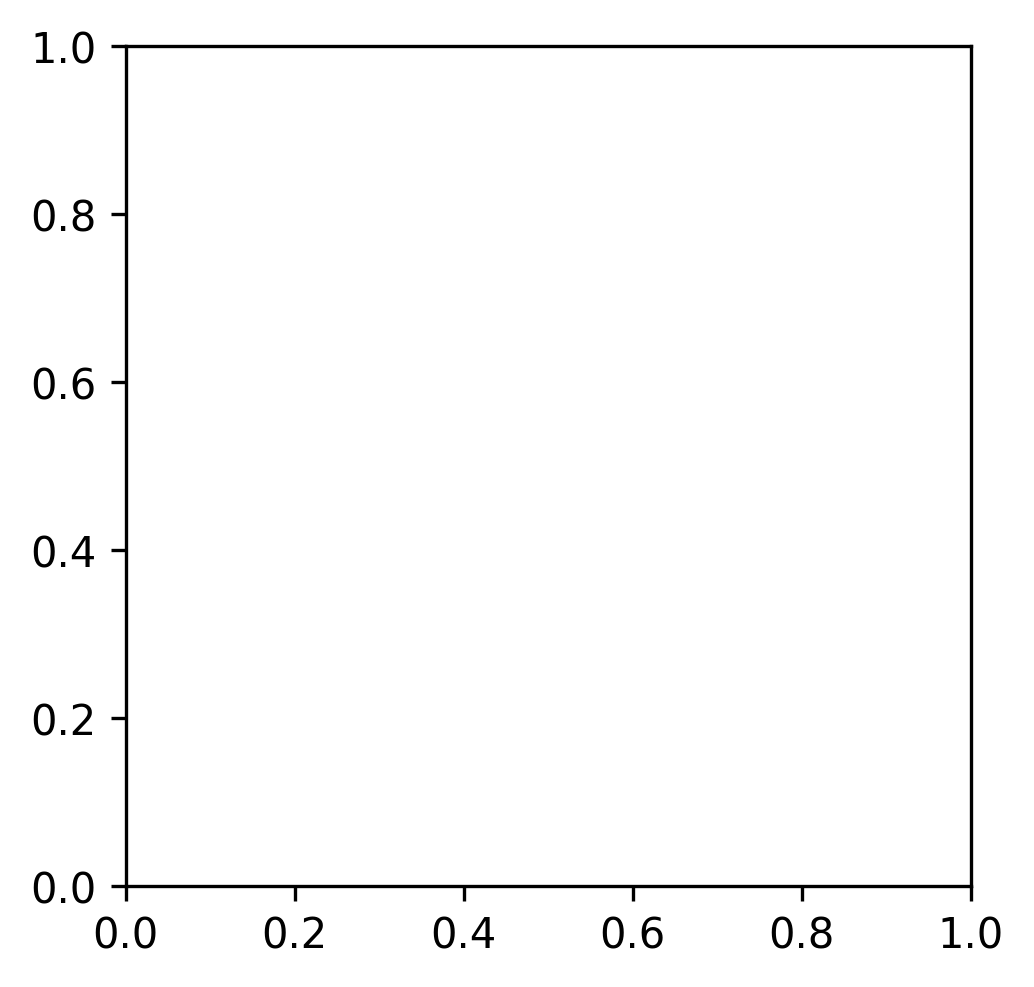

In [49]:
plt.figure(dpi = 300, figsize=(8,8))
plt.subplot(221)
plt.imshow(donn.does[0].height_map.detach().cpu().numpy())    
plt.colorbar()
plt.subplot(222)
plt.imshow(donn.does[1].height_map.detach().cpu().numpy())
plt.colorbar()
plt.subplot(223)
plt.imshow(donn.does[2].height_map.detach().cpu().numpy())
plt.colorbar()
plt.subplot(224)
plt.imshow(donn.does[2].height_map.detach().cpu().numpy())
plt.colorbar()

The critical distance is [0.26003873] m, the TF will be fine during the sampling !
The critical distance is [0.26003873] m, the TF will be fine during the sampling !
The critical distance is [0.26003873] m, the TF will be fine during the sampling !
The critical distance is [0.26003873] m, the TF will be fine during the sampling !
The critical distance is [0.26003873] m, the TF will be fine during the sampling !


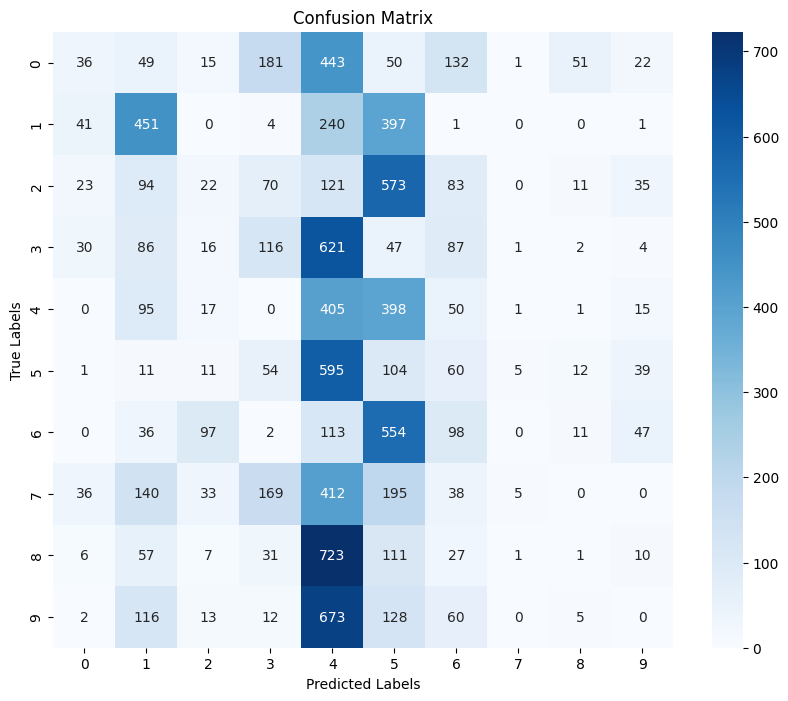

In [50]:
import seaborn as sns
matrix, test_acc, I, labels = conf_matrix(donn, test_loader, criterion, iter_frac=1)
# Optionally, plot the confusion matrix using seaborn's heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

In [51]:
test_acc

0.1238132911392405

In [18]:
np.save('ste_conf_matrix.npy', matrix)

In [135]:
80 / 256

0.3125

In [64]:
# 5. Training the model with different quantized methods

from torch import optim

################ train ###############################
file_path = 'model'
if os.path.exists(file_path) == False:
    os.makedirs(file_path)

device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

donn1 = DONN(input_dxy=input_dxy, 
            input_field_shape=input_field_shape, 
            doe_params=doe_params, 
            optim_params=optim_params,
            wavelengths=wavelengths, 
            num_layer=num_layer,
            d_layer=d_layer, 
            q_method='ste', 
            device=device)

epoch_num = 50
optimizer = optim.AdamW(donn.parameters(), lr=0.1)
criterion = npcc_loss

################################ train ####################################
start_time = time.time()
donn1, train_losses, train_accies, val_losses, val_accies, I_val, labels_val =\
            train(donn1,criterion, optimizer,
                  train_loader,val_loader, 
                  file_path, epoch_num)    
    
end_time = time.time()
print(f'runing time: {end_time - start_time: 5f}s')

The critical distance is [0.04478689] m, the TF will be fine during the sampling !
The critical distance is [0.04478689] m, the TF will be fine during the sampling !
The critical distance is [0.04478689] m, the TF will be fine during the sampling !
The critical distance is [0.04478689] m, the TF will be fine during the sampling !
The critical distance is [0.04478689] m, the TF will be fine during the sampling !
epoch 1 200, train loss: -0.020305,train accuracy:  0.083594 
 validation loss:-0.020362, validation accuracy: 0.081641
epoch 1 400, train loss: -0.020382,train accuracy:  0.082422 
 validation loss:-0.020497, validation accuracy: 0.081250
epoch 2 200, train loss: -0.020360,train accuracy:  0.082227 
 validation loss:-0.020457, validation accuracy: 0.080469
epoch 2 400, train loss: -0.020360,train accuracy:  0.083711 
 validation loss:-0.020473, validation accuracy: 0.079102
epoch 3 200, train loss: -0.020374,train accuracy:  0.082109 
 validation loss:-0.020460, validation accu


KeyboardInterrupt



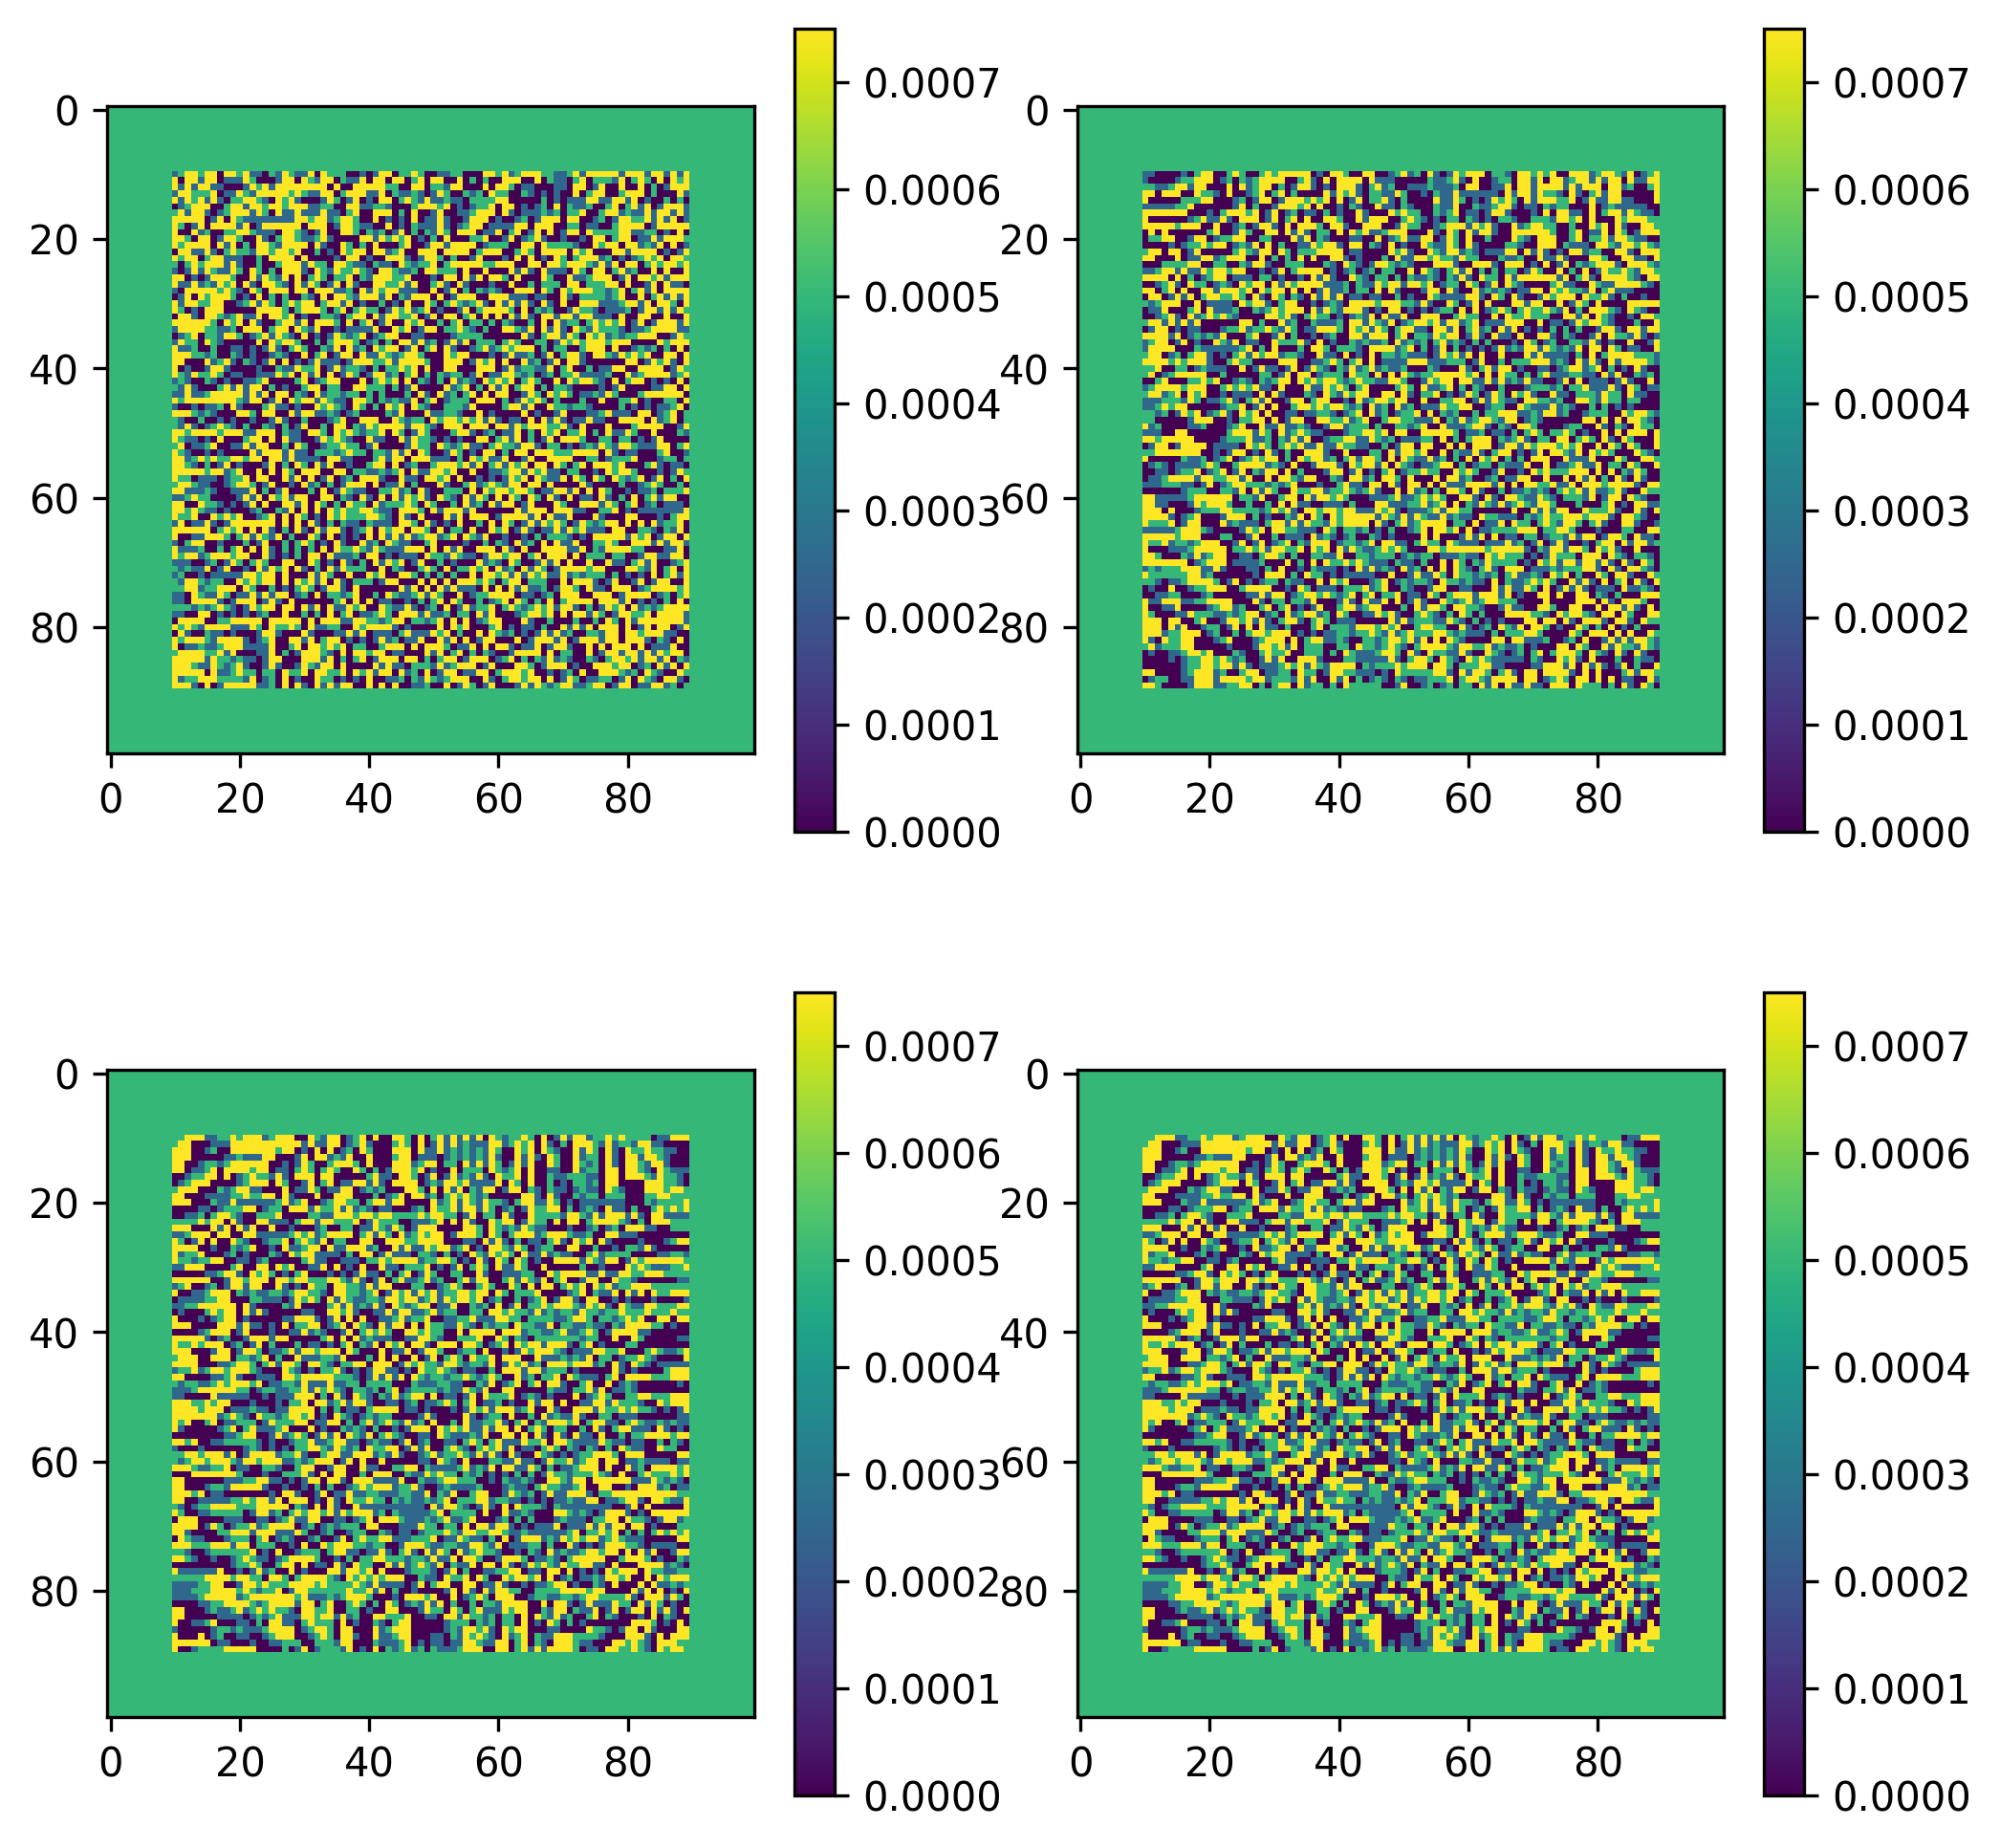

In [29]:
plt.figure(dpi = 300, figsize=(8,8))
plt.subplot(221)
plt.imshow(donn.does[0].height_map.detach().cpu().numpy())    
plt.colorbar()
plt.subplot(222)
plt.imshow(donn.does[1].height_map.detach().cpu().numpy())
plt.colorbar()
plt.subplot(223)
plt.imshow(donn.does[2].height_map.detach().cpu().numpy())
plt.colorbar()
plt.subplot(224)
plt.imshow(donn.does[2].height_map.detach().cpu().numpy())
plt.colorbar()

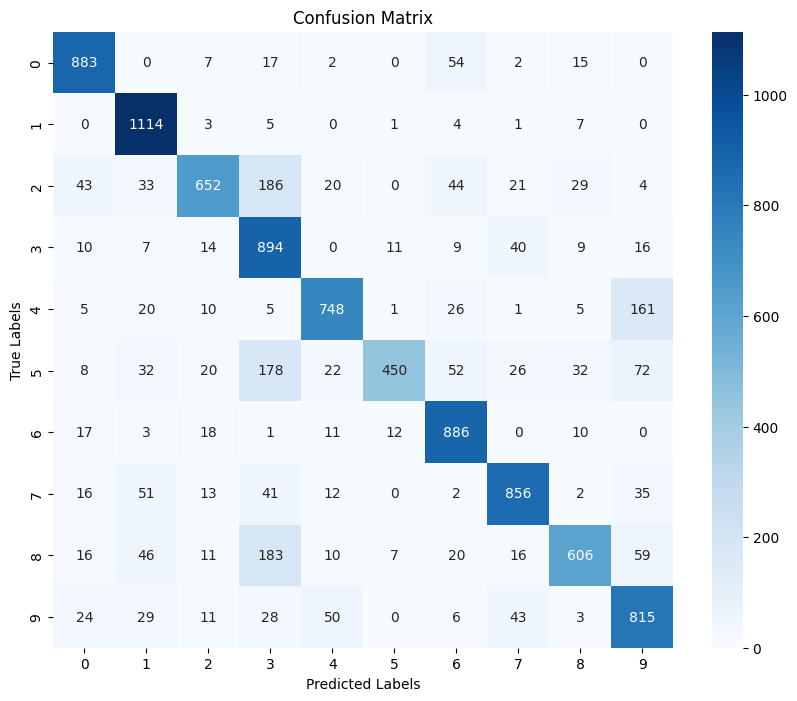

In [28]:
import seaborn as sns
matrix = conf_matrix(donn, test_loader, criterion, iter_frac=1)
# Optionally, plot the confusion matrix using seaborn's heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()